<a href="https://colab.research.google.com/github/naseealavutheen1805/Hotel-Operation-Analysis/blob/main/Hotel_Operation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Introduction**

> This project analyzes hotel booking data to understand booking patterns, customer behavior, cancellation trends, and revenue performance. The objective is to generate insights that can help improve hotel operations, enhance guest satisfaction, and support better business decision-making through data analysis.


**Import Libraries and Files**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv.zip')

**Data Understanding**

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [7]:
df.shape

(119390, 32)

**Data Cleaning**

In [8]:
df.isnull().mean() * 100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


In [9]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [10]:
df = df.rename(columns={
    'Hotel': 'Hotel',
    'Is_Canceled': 'Is_canceled',
    'lead_time': 'lead_time',
    'arrival_date_year': 'arrival_year',
    'arrival_date_month': 'arrival_month',
    'arrival_date_week_number': 'arrival_week',
    'arrival_date_day_of_month': 'arrival_day',
    'stays_in_weekend_nights': 'weekend_nights',
    'stays_in_week_nights': 'week_nights',
    'adults': 'adults',
    'children': 'children',
    'babies': 'babies',
    'meal': 'meal',
    'country': 'country',
    'markter_segment': 'market_segment',
    'distribution_channel': 'distribution_channel',
    'is_repeated_guest': 'is_repeated_guest',
    'previous_cancellations': 'previous_cancellations',
    'previous_bookings_not_canceled': 'previous_bookings_not_canceled',
    'reserved_room_type': 'reserved_room_type',
    'assigned_room_type':'ssigned_room_type',
    'booking_changes': 'booking_changes',
    'deposit_type': 'deposit_type',
    'agent': 'agent',
    'company': 'company',
    'days_in_waiting_list': 'waiting_list_days',
    'customer_type': 'customer_type',
    'adr': 'adr',
    'required_car_parking_spaces': 'parking_spaces',
    'total_of_special_requests': 'special_requests',
    'reservation_status': 'reservation_status',
    'reservation_status_date': 'reservation_status_date'
})

In [11]:
df.columns = df.columns.str.strip().str.title()

In [12]:
df.columns

Index(['Hotel', 'Is_Canceled', 'Lead_Time', 'Arrival_Year', 'Arrival_Month',
       'Arrival_Week', 'Arrival_Day', 'Weekend_Nights', 'Week_Nights',
       'Adults', 'Children', 'Babies', 'Meal', 'Country', 'Market_Segment',
       'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations',
       'Previous_Bookings_Not_Canceled', 'Reserved_Room_Type',
       'Ssigned_Room_Type', 'Booking_Changes', 'Deposit_Type', 'Agent',
       'Company', 'Waiting_List_Days', 'Customer_Type', 'Adr',
       'Parking_Spaces', 'Special_Requests', 'Reservation_Status',
       'Reservation_Status_Date'],
      dtype='object')

In [13]:
df['Reservation_Status_Date'] = pd.to_datetime(df['Reservation_Status_Date'])

In [14]:
df['Country'].fillna('Unknown', inplace=True)
df['Agent'].fillna(0, inplace=True)
df['Company'].fillna(0, inplace=True)
df['Children'].fillna(0, inplace=True)

/tmp/ipykernel_3758/3831126041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna('Unknown', inplace=True)
/tmp/ipykernel_3758/3831126041.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [15]:
df.duplicated().sum()

np.int64(31994)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.shape

(87396, 32)

In [18]:
df.isnull().sum()

,0
Hotel,0
Is_Canceled,0
Lead_Time,0
Arrival_Year,0
Arrival_Month,0
Arrival_Week,0
Arrival_Day,0
Weekend_Nights,0
Week_Nights,0
Adults,0


In [19]:
df.head()

,Hotel,Is_Canceled,Lead_Time,Arrival_Year,Arrival_Month,Arrival_Week,Arrival_Day,Weekend_Nights,Week_Nights,Adults,...,Deposit_Type,Agent,Company,Waiting_List_Days,Customer_Type,Adr,Parking_Spaces,Special_Requests,Reservation_Status,Reservation_Status_Date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


**Key Metrics**

**Booking Lead Time Analysis**

In [20]:
avg_lead_time = round(df['Lead_Time'].mean(), 4)
print(avg_lead_time)
cancellation_rate = round(df['Is_Canceled'].mean() * 100, 4)
print(cancellation_rate)

79.8914
27.4898


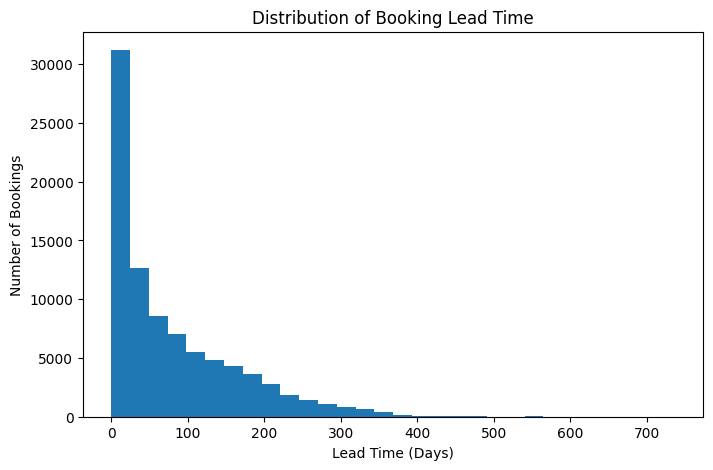

In [21]:
plt.figure(figsize=(8,5))
df['Lead_Time'].plot(kind='hist', bins=30)
plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')
plt.show()

**Cancellation Rate Analysis**

In [22]:
cancellation_rate = round(df['Is_Canceled'].mean()*100,2)

print("Cancellation Rate:", cancellation_rate,"%")

Cancellation Rate: 27.49 %


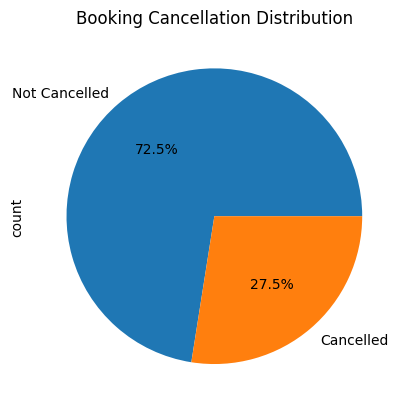

In [23]:
cancel_data = df['Is_Canceled'].value_counts()

cancel_data.plot(kind='pie', autopct='%1.1f%%', labels=['Not Cancelled','Cancelled'])

plt.title('Booking Cancellation Distribution')

plt.show()

**Occupancy Rate**

In [24]:
df['Total_Nights'] = df['Week_Nights'] + df['Weekend_Nights']

avg_stay = round(df['Total_Nights'].mean(), 2)

print("Average Stay Duration:", avg_stay)

Average Stay Duration: 3.63


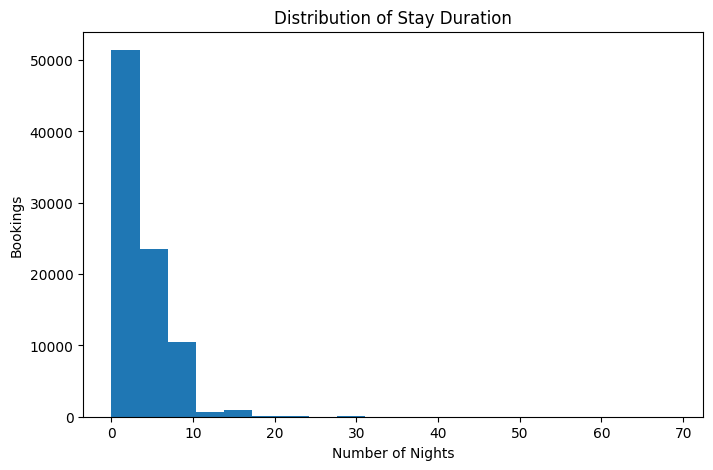

In [25]:
plt.figure(figsize=(8,5))
df['Total_Nights'].plot(kind='hist', bins=20)
plt.title('Distribution of Stay Duration')
plt.xlabel('Number of Nights')
plt.ylabel('Bookings')
plt.show()

**Special Requests Analysis**

In [26]:
avg_requests = round(df['Special_Requests'].mean(),2)

print("Average Special Requests:", avg_requests)

Average Special Requests: 0.7


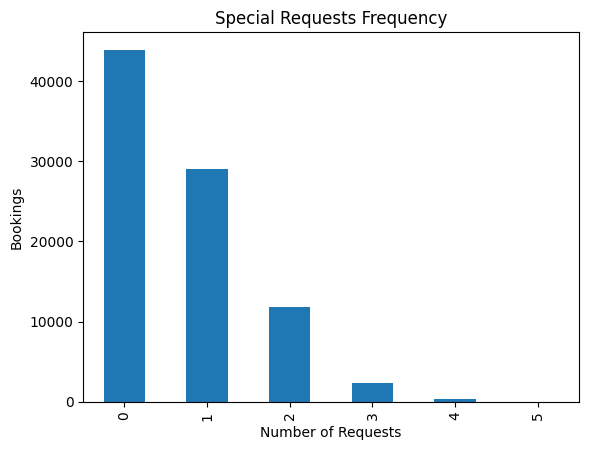

In [27]:
df['Special_Requests'].value_counts().sort_index().plot(kind='bar')

plt.title('Special Requests Frequency')
plt.xlabel('Number of Requests')
plt.ylabel('Bookings')

plt.show()

**Revenue Metrics Analysis**

**ADR**

In [28]:
 Adr = round(df['Adr'].mean(), 2)
 print(Adr)

106.34


**Adr by Hotel Type**

In [29]:
df.groupby('Hotel')['Adr'].mean()

,Adr
Hotel,
City Hotel,110.985944
Resort Hotel,99.025346


<Axes: xlabel='Hotel'>

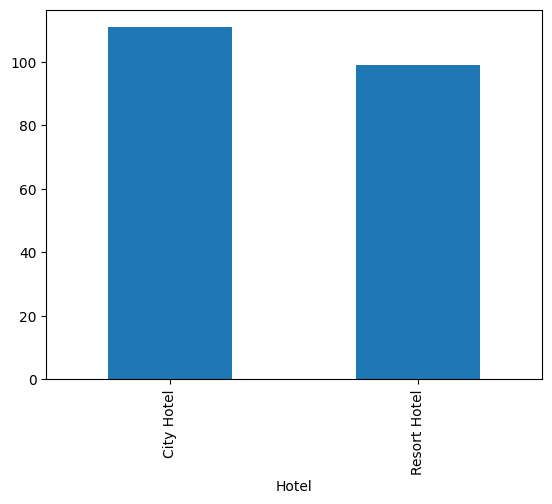

In [30]:
df.groupby('Hotel')['Adr'].mean().plot(kind='bar')

In [31]:
 df.groupby('Hotel')['Adr'].sum()


,Adr
Hotel,
City Hotel,5929757.03
Resort Hotel,3363692.96


In [32]:
df['Hotel'].value_counts()

,count
Hotel,
City Hotel,53428
Resort Hotel,33968


**Monthly Revenue Trend**

In [33]:
month_order = [
     'January', 'February','March', 'April', 'May', 'June','July','August','September','October','November','December'
]


In [34]:
Monthly_Revenue_Trend = df.groupby('Arrival_Month')['Adr'].mean().reindex(month_order)
print(Monthly_Revenue_Trend)

Arrival_Month
January       70.050742
February      74.692033
March         81.609523
April        103.612589
May          111.195703
June         119.750120
July         135.542014
August       150.876120
September    112.081263
October       90.152518
November      72.754460
December      81.450226
Name: Adr, dtype: float64


Text(0.5, 0, 'Month')

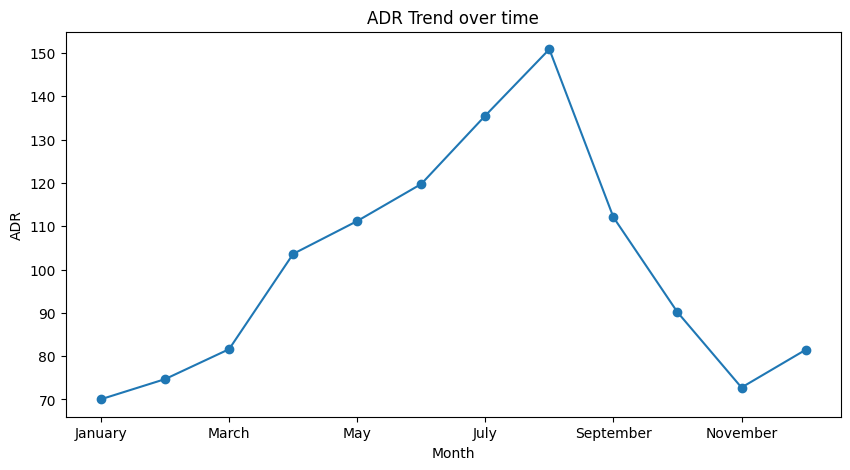

In [35]:
plt.figure(figsize=(10,5))
Monthly_Revenue_Trend.plot(kind='line', marker='o')
plt.title('ADR Trend over time')
plt.ylabel('ADR')
plt.xlabel('Month')

**Monthly Booking Analysis**

In [36]:
monthly_bookings = df['Arrival_Month'].value_counts().reindex(month_order)
print(monthly_bookings)

Arrival_Month
January       4693
February      6098
March         7513
April         7908
May           8355
June          7765
July         10057
August       11257
September     6690
October       6934
November      4995
December      5131
Name: count, dtype: int64


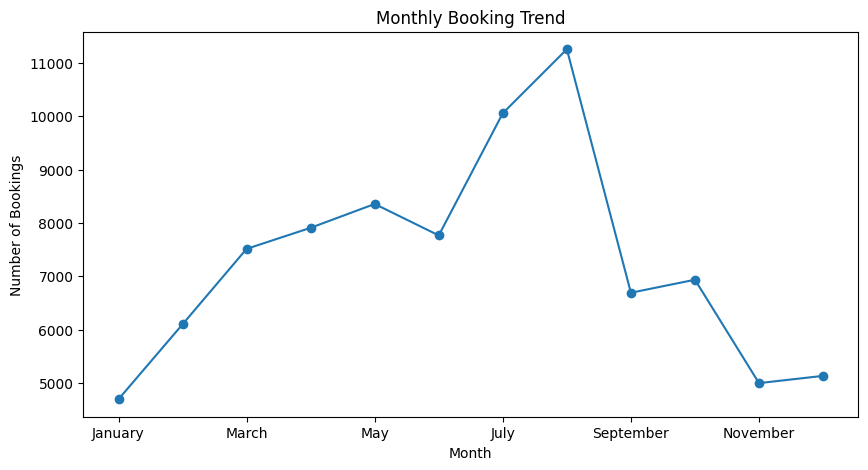

In [37]:
plt.figure(figsize=(10,5))
monthly_bookings.plot(kind='line', marker='o')
plt.title('Monthly Booking Trend')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.show()

**Guest Preference Analysis**

**Country-Wise Guests**

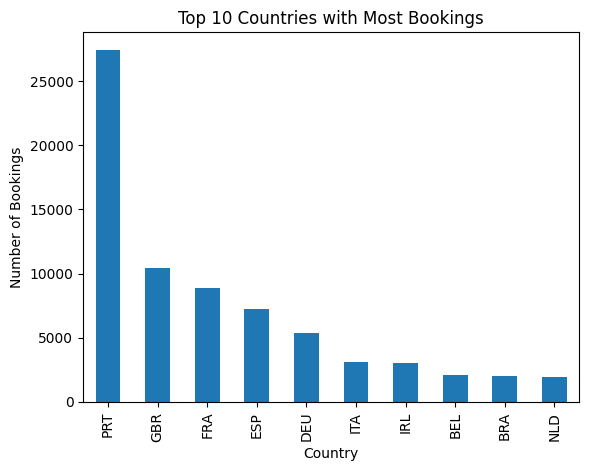

In [38]:
Top_countries = df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries with Most Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.show()


**Revenue Management Analysis**

**Adr Trend Over Years**

In [39]:
Yearly_adr = round(df.groupby('Arrival_Year')['Adr'].mean(), 2)
print(Yearly_adr)

Arrival_Year
2015     92.16
2016    101.54
2017    118.71
Name: Adr, dtype: float64


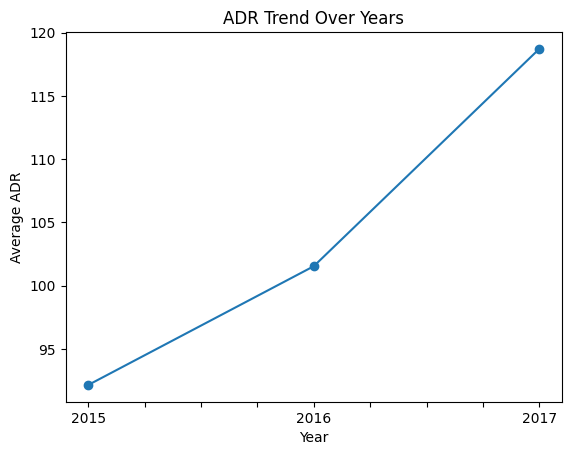

In [40]:
Yearly_adr.index = Yearly_adr.index.astype(str)
Yearly_adr.plot(kind='line', marker='o')
plt.title('ADR Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Average ADR')
plt.show()

In [41]:
Cancellation = round(df['Is_Canceled'].mean(),4)
print(Cancellation)

0.2749


In [42]:
(df['Is_Canceled'].mean())*100

np.float64(27.489816467572886)

In [43]:
df.groupby('Hotel')['Is_Canceled'].mean()*100

,Is_Canceled
Hotel,
City Hotel,30.038557
Resort Hotel,23.480923


In [44]:
Monthly_Cancellation_Trend = df.groupby('Arrival_Month')['Is_Canceled'].mean().reindex(month_order)
print(Monthly_Cancellation_Trend)

Arrival_Month
January      0.221180
February     0.232043
March        0.243578
April        0.304628
May          0.292280
June         0.303155
July         0.317987
August       0.321844
September    0.245441
October      0.236804
November     0.211011
December     0.268564
Name: Is_Canceled, dtype: float64


Text(0.5, 0, 'Month')

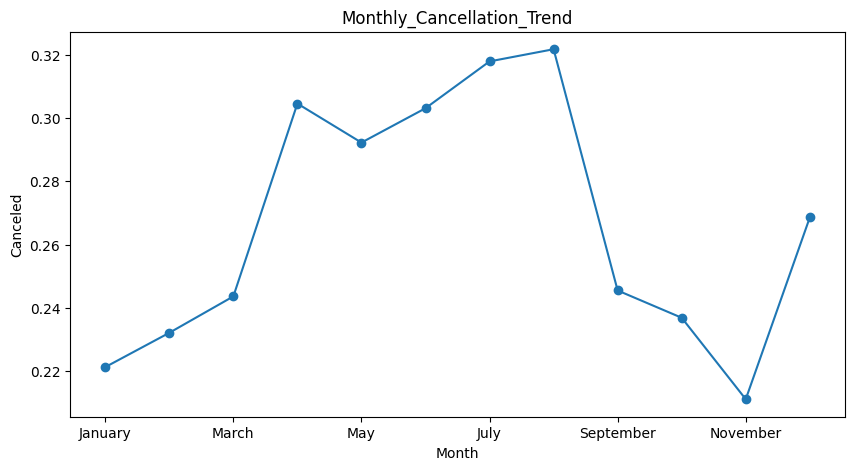

In [45]:
plt.figure(figsize=(10,5))
Monthly_Cancellation_Trend.plot(kind='line', marker='o')
plt.title('Monthly_Cancellation_Trend')
plt.ylabel('Canceled')
plt.xlabel('Month')

In [46]:
df['Is_Repeated_Guest'].value_counts()

,count
Is_Repeated_Guest,
0,83981
1,3415


In [47]:
df['Week_Nights'].mean()

np.float64(2.6253947549086916)

In [48]:
family = df['Adults'] + df['Children'] + df['Babies']

In [49]:
df['Reserved_Room_Type'].value_counts()

,count
Reserved_Room_Type,
A,56552
D,17398
E,6049
F,2823
G,2052
B,999
C,915
H,596
L,6


In [50]:
df['Booking_Changes'].mean()

np.float64(0.27160281935100006)

In [51]:
df['Waiting_List_Days'].mean()

np.float64(0.7495651974918761)

In [52]:
df['Market_Segment'].value_counts()

,count
Market_Segment,
Online TA,51618
Offline TA/TO,13889
Direct,11804
Groups,4942
Corporate,4212
Complementary,702
Aviation,227
Undefined,2


In [53]:
df['Distribution_Channel'].value_counts()

,count
Distribution_Channel,
TA/TO,69141
Direct,12988
Corporate,5081
GDS,181
Undefined,5


**Conclusion**

The analysis provided valuable insights into hotel booking trends, customer behavior, cancellation patterns, and revenue performance. The findings highlighted peak booking periods, major customer segments, and operational factors affecting hotel performance. Overall, the analysis can support better decision-making to improve guest satisfaction, operational efficiency, and revenue management.

**Recommendations**

* Optimize pricing strategies during high-demand booking periods to improve revenue generation.
* Reduce cancellation rates by improving booking policies and customer communication.
* Focus marketing efforts on major customer regions and high-performing market segments.
* Improve operational planning during peak seasons to enhance guest experience and service quality.
* Monitor guest preferences and special requests to provide more personalized hospitality services.
